# Import Libraries & DataSet

In [ ]:
#! pip install pandas
#! pip install nltk numpy matplotlib seaborn wordcloud scikit-learn tensorflow


In [ ]:
import pandas as pd
import re
import pickle
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, SpatialDropout1D, Input
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset 

In [ ]:
df = pd.read_csv('capitals_dataset_Final_Corpus_FINAL.csv')

# DISPLAY DATASET 

In [ ]:
df.head()

,Capitals Text Generation,Sentiment Label,Predicted Capital,User-Id,Social-Accounts,Date,Time,Day,Country,Age-Of-User
0,"💸 Financial growth is not good,",Negative,Economic Capital,3208,LinkedIn,2024-03-24,08:39:41,Sunday,Germany,23
1,"🖌️ Morgan’s designs were not good, even with g...",Negative,Creative Capital,2597,Flickr,2024-05-30,08:39:42,Thursday,France,16
2,🔄 He repeats bad failures. 🔄,Negative,Human Leadership Capital,7841,Instagram,2024-02-27,08:39:36,Tuesday,Sweden,15
3,😠 Poor emotional handling led to not good team...,Negative,Emotional Capital,8860,Baidu Tieba,2024-05-18,08:39:38,Saturday,Philippines,16
4,🎓 Years of practical work built my confidence!,Positive,Experiential Capital,8392,TikTok,2024-02-22,08:39:41,Thursday,Thailand,42


In [ ]:
df.tail()

,Capitals Text Generation,Sentiment Label,Predicted Capital,User-Id,Social-Accounts,Date,Time,Day,Country,Age-Of-User
336024,🌟 Faith is not bad for providing strength and ...,Positive,Religious Capital,7677,Tumblr,2023-12-25,08:39:37,Monday,Iran,18
336025,😟 A damaged reputation hindered their competit...,Negative,Reputational Capital,4455,Instagram,2023-12-26,08:39:42,Tuesday,Italy,23
336026,😔 Negative interactions cause disruption in gr...,Negative,Social Capital,9732,Twitter,2023-11-06,08:39:37,Monday,Sweden,27
336027,"🤝 The community didn't lack strong support, cr...",Positive,Social Capital,4801,Periscope,2023-12-09,08:39:37,Saturday,Canada,20
336028,🔋 The solar-powered devices contributed to sus...,Positive,Physical Capital,1056,YouTube,2024-08-04,08:39:40,Sunday,Egypt,29


# Data Set Shape

In [ ]:
df.shape

(336029, 10)

# CHECKING DTYPES 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336029 entries, 0 to 336028
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Capitals Text Generation  336029 non-null  object
 1   Sentiment Label           336029 non-null  object
 2   Predicted Capital         336029 non-null  object
 3   User-Id                   336029 non-null  int64 
 4   Social-Accounts           336029 non-null  object
 5   Date                      336029 non-null  object
 6   Time                      336029 non-null  object
 7   Day                       336029 non-null  object
 8   Country                   336029 non-null  object
 9   Age-Of-User               336029 non-null  int64 
dtypes: int64(2), object(8)
memory usage: 25.6+ MB


# Summary Statistics 

In [ ]:
df.describe()

,User-Id,Age-Of-User
count,336029.000000,336029.000000
mean,5500.486863,34.939966
std,2600.973136,17.071688
min,1000.000000,13.000000
25%,3244.000000,19.000000
50%,5501.000000,32.000000
75%,7760.000000,47.000000
max,9999.000000,75.000000


# Step 1: Data Preprocessing


# Define function to remove emojis and unnecessary characters

In [ ]:
# def remove_unnecessary_characters(text):
   #  text = re.sub(r'<.*?>', '', str(text))
   #  text = re.sub(r'[^a-zA-Z0-9\s]', '', str(text))
   #  text = re.sub(r'\s+', ' ', str(text)).strip()
   #  return text 

def remove_unnecessary_characters(text):
    text = str(text)

    # Keep "not" and other negation words safe
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z\s']", " ", text)   # keep apostrophes & letters
    text = re.sub(r"\s+", " ", text).strip()

    return text

def handle_negation(text):
    text = text.replace("not ", "not_")
    text = text.replace("never ", "never_")
    return text



In [ ]:
 # df['Clean_Capitals Text Generation'] = df['Capitals Text Generation'].apply(remove_unnecessary_characters)

df['Clean_Text'] = df['Text'].apply(remove_unnecessary_characters).apply(handle_negation)


# Display the first few rows to check the cleaning

In [ ]:
df.head()

,Capitals Text Generation,Sentiment Label,Predicted Capital,User-Id,Social-Accounts,Date,Time,Day,Country,Age-Of-User,Clean_Capitals Text Generation
0,"💸 Financial growth is not good,",Negative,Economic Capital,3208,LinkedIn,2024-03-24,08:39:41,Sunday,Germany,23,Financial growth is not good
1,"🖌️ Morgan’s designs were not good, even with g...",Negative,Creative Capital,2597,Flickr,2024-05-30,08:39:42,Thursday,France,16,Morgans designs were not good even with good f...
2,🔄 He repeats bad failures. 🔄,Negative,Human Leadership Capital,7841,Instagram,2024-02-27,08:39:36,Tuesday,Sweden,15,He repeats bad failures
3,😠 Poor emotional handling led to not good team...,Negative,Emotional Capital,8860,Baidu Tieba,2024-05-18,08:39:38,Saturday,Philippines,16,Poor emotional handling led to not good team d...
4,🎓 Years of practical work built my confidence!,Positive,Experiential Capital,8392,TikTok,2024-02-22,08:39:41,Thursday,Thailand,42,Years of practical work built my confidence


# TOKENIZATION

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

In [ ]:
def tokenize_text(text):
    try:
        text = str(text)
        tokens = word_tokenize(text)
        return tokens
    except Exception as e:
        print(f"Error tokenizing text: {e}")
        return []

df['Tokens'] = df['Clean_Capitals Text Generation'].apply(tokenize_text)

In [ ]:
df.head()

,Capitals Text Generation,Sentiment Label,Predicted Capital,User-Id,Social-Accounts,Date,Time,Day,Country,Age-Of-User,Clean_Capitals Text Generation,Tokens
0,"💸 Financial growth is not good,",Negative,Economic Capital,3208,LinkedIn,2024-03-24,08:39:41,Sunday,Germany,23,Financial growth is not good,"[Financial, growth, is, not, good]"
1,"🖌️ Morgan’s designs were not good, even with g...",Negative,Creative Capital,2597,Flickr,2024-05-30,08:39:42,Thursday,France,16,Morgans designs were not good even with good f...,"[Morgans, designs, were, not, good, even, with..."
2,🔄 He repeats bad failures. 🔄,Negative,Human Leadership Capital,7841,Instagram,2024-02-27,08:39:36,Tuesday,Sweden,15,He repeats bad failures,"[He, repeats, bad, failures]"
3,😠 Poor emotional handling led to not good team...,Negative,Emotional Capital,8860,Baidu Tieba,2024-05-18,08:39:38,Saturday,Philippines,16,Poor emotional handling led to not good team d...,"[Poor, emotional, handling, led, to, not, good..."
4,🎓 Years of practical work built my confidence!,Positive,Experiential Capital,8392,TikTok,2024-02-22,08:39:41,Thursday,Thailand,42,Years of practical work built my confidence,"[Years, of, practical, work, built, my, confid..."


# Data Normalization 

In [ ]:
def normalize_text(text):
    if isinstance(text, str):
        text = text.lower()  # Convert text to lowercase
        text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
        text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    else:
        text = str(text)  # Convert non-string inputs to string
    return text

# Apply normalize_text function to the 'clean_Capitals Text Generation' column
df['Normalized_text'] = df['Clean_Capitals Text Generation'].apply(normalize_text)

In [ ]:
df.head()

,Capitals Text Generation,Sentiment Label,Predicted Capital,User-Id,Social-Accounts,Date,Time,Day,Country,Age-Of-User,Clean_Capitals Text Generation,Tokens,Normalized_text
0,"💸 Financial growth is not good,",Negative,Economic Capital,3208,LinkedIn,2024-03-24,08:39:41,Sunday,Germany,23,Financial growth is not good,"[Financial, growth, is, not, good]",financial growth is not good
1,"🖌️ Morgan’s designs were not good, even with g...",Negative,Creative Capital,2597,Flickr,2024-05-30,08:39:42,Thursday,France,16,Morgans designs were not good even with good f...,"[Morgans, designs, were, not, good, even, with...",morgans designs were not good even with good f...
2,🔄 He repeats bad failures. 🔄,Negative,Human Leadership Capital,7841,Instagram,2024-02-27,08:39:36,Tuesday,Sweden,15,He repeats bad failures,"[He, repeats, bad, failures]",he repeats bad failures
3,😠 Poor emotional handling led to not good team...,Negative,Emotional Capital,8860,Baidu Tieba,2024-05-18,08:39:38,Saturday,Philippines,16,Poor emotional handling led to not good team d...,"[Poor, emotional, handling, led, to, not, good...",poor emotional handling led to not good team d...
4,🎓 Years of practical work built my confidence!,Positive,Experiential Capital,8392,TikTok,2024-02-22,08:39:41,Thursday,Thailand,42,Years of practical work built my confidence,"[Years, of, practical, work, built, my, confid...",years of practical work built my confidence


# Removing Stopwords 

In [ ]:
from nltk.corpus import stopwordss

# Load default English stopwords
stop_words = set(stopwords.words('english'))

# Meaningful words you want to keep (not removed)
meaningful_words = {
    'not', 'no', 'nor', 'never', 'very', 'only', 'few', 'many', 'most', 'much', 'against'
}

# Remove them from stopwords list
stop_words = stop_words - meaningful_words

# Apply after tokenization
df['Text_without_stopwords'] = df['Tokens'].apply(
    lambda tokens: ' '.join([word for word in tokens if word.lower() not in stop_words])
)

[nltk_data] Downloading package stopwords to C:\Users\roohullah-
[nltk_data]     pc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


{'weren', 'mustn', 'and', 's', 'what', "you'd", 'had', 'were', 'on', 'this', 'her', 'off', 'being', "you'll", 'such', 'into', 'myself', 'yourself', 'herself', 'between', 'an', "he'd", 'so', 'we', 'doing', 'your', 'me', 'he', 'did', "i'm", 'the', 'd', "he's", 'its', "she'd", 'o', "she's", "i'd", "they've", 'below', "should've", 'ours', "they're", 'hasn', 'above', 'over', "isn't", 'itself', 'up', 'didn', 'both', 'few', 'my', 'been', 'shouldn', "you're", 'in', "i'll", "aren't", 'wouldn', 'that', "didn't", "he'll", 'needn', 'most', 'as', 'after', 'is', 'they', 'aren', 'where', 'why', 'there', 'his', 'to', 'how', 'i', 'of', 'those', 'don', "weren't", 'do', 'whom', 'yours', "wasn't", 'from', 'can', 're', 'here', 'than', "you've", 'hers', 'before', "it'd", 'against', 'theirs', 'hadn', 'about', 'only', 'yourselves', "it'll", 'some', 'again', 'at', 'ma', 'are', 've', 'shan', 'each', 'these', "that'll", "we'd", "we're", 'y', 'am', 'couldn', 'haven', "i've", 'does', 'for', "she'll", 'll', 'won', 

In [ ]:
# Display a few examples of the cleaned text
print(df[['Text_without_stopwords']].head())

                              Text_without_stopwords
0                          Financial growth not good
1  Morgans designs not good even good feedback re...
2                               repeats bad failures
3  Poor emotional handling led not good team dyna...
4              Years practical work built confidence


In [ ]:
df.head()

,Capitals Text Generation,Sentiment Label,Predicted Capital,User-Id,Social-Accounts,Date,Time,Day,Country,Age-Of-User,Clean_Capitals Text Generation,Tokens,Normalized_text,Text_without_stopwords
0,"💸 Financial growth is not good,",Negative,Economic Capital,3208,LinkedIn,2024-03-24,08:39:41,Sunday,Germany,23,Financial growth is not good,"[Financial, growth, is, not, good]",financial growth is not good,Financial growth not good
1,"🖌️ Morgan’s designs were not good, even with g...",Negative,Creative Capital,2597,Flickr,2024-05-30,08:39:42,Thursday,France,16,Morgans designs were not good even with good f...,"[Morgans, designs, were, not, good, even, with...",morgans designs were not good even with good f...,Morgans designs not good even good feedback re...
2,🔄 He repeats bad failures. 🔄,Negative,Human Leadership Capital,7841,Instagram,2024-02-27,08:39:36,Tuesday,Sweden,15,He repeats bad failures,"[He, repeats, bad, failures]",he repeats bad failures,repeats bad failures
3,😠 Poor emotional handling led to not good team...,Negative,Emotional Capital,8860,Baidu Tieba,2024-05-18,08:39:38,Saturday,Philippines,16,Poor emotional handling led to not good team d...,"[Poor, emotional, handling, led, to, not, good...",poor emotional handling led to not good team d...,Poor emotional handling led not good team dyna...
4,🎓 Years of practical work built my confidence!,Positive,Experiential Capital,8392,TikTok,2024-02-22,08:39:41,Thursday,Thailand,42,Years of practical work built my confidence,"[Years, of, practical, work, built, my, confid...",years of practical work built my confidence,Years practical work built confidence


# SENTIMENT VALUECOUNTS

C:\Users\roohullah-pc\AppData\Local\Temp\ipykernel_29280\4080150020.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment Label', palette='viridis')


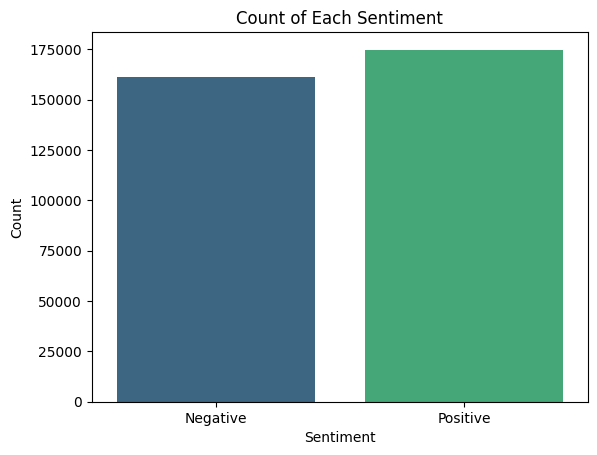

In [ ]:
sns.countplot(data=df, x='Sentiment Label', palette='viridis')
plt.title('Count of Each Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


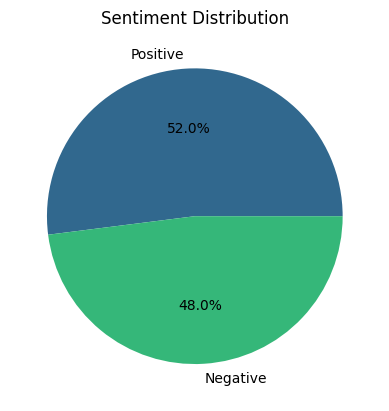

In [ ]:
df['Sentiment Label'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('viridis', len(df['Sentiment Label'].unique())))
plt.title('Sentiment Distribution')
plt.ylabel('')
plt.show()


In [ ]:
!pip install wordcloud


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


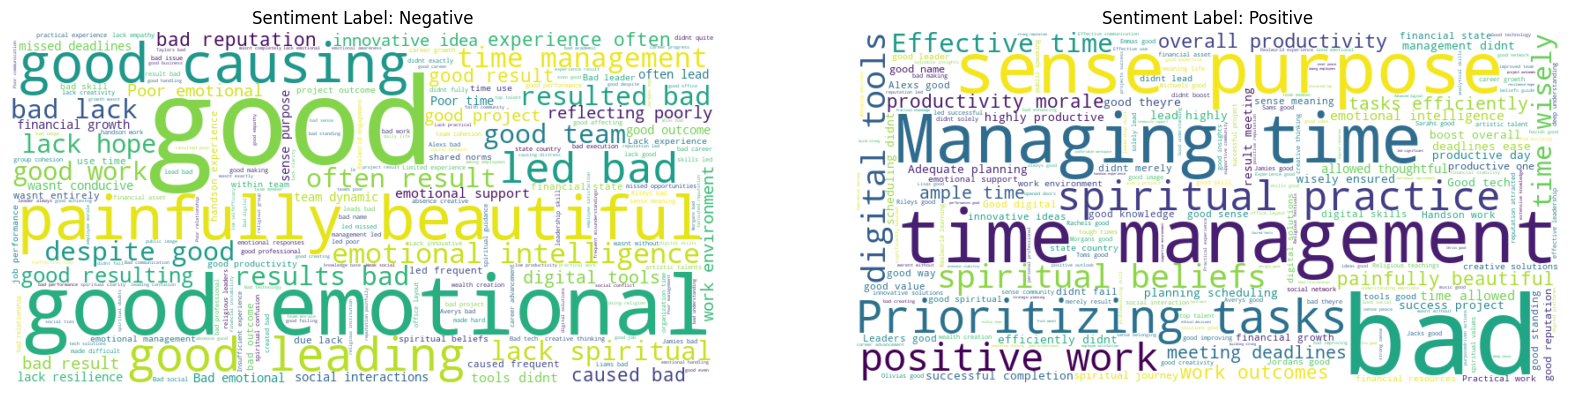

In [ ]:
from wordcloud import WordCloud

sentiments = df['Sentiment Label'].unique()
plt.figure(figsize=(20, 10))
for i, sentiment in enumerate(sentiments):
    plt.subplot(1, len(sentiments), i+1)
    text = ' '.join(df[df['Sentiment Label'] == sentiment]['Text_without_stopwords'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Sentiment Label: {sentiment}')
plt.show()


In [ ]:
df['Sentiment Label'].value_counts()

Sentiment Label
Positive    174735
Negative    161294
Name: count, dtype: int64

In [ ]:
df['text_length'] = df['Text_without_stopwords'].apply(len)


In [ ]:
df['text_length']

0         25
1         52
2         20
3         50
4         37
          ..
336024    43
336025    44
336026    45
336027    64
336028    55
Name: text_length, Length: 336029, dtype: int64

# Count the occurrences of each capital

In [ ]:
capital_counts = df['Predicted Capital'].value_counts()
capital_counts

Predicted Capital
Economic Capital            22600
Social Capital              22400
Emotional Capital           22200
Digital Capital             21600
Cultural Capital            21400
Creative Capital            21200
Temporal Capital            21050
Physical Capital            21000
Intellectual Capital        20800
Organizational Capital      20600
Experiential Capital        20500
Human Leadership Capital    20400
Religious Capital           20200
Psychological Capital       20050
Reputational Capital        20029
Spiritual Capital           20000
Name: count, dtype: int64

# Identify the most and least used capitals

In [ ]:
most_used = capital_counts.idxmax()
least_used = capital_counts.idxmin()

In [ ]:
most_used

'Economic Capital'

In [ ]:
least_used

'Spiritual Capital'

In [ ]:
df_filtered = df[df['Predicted Capital'].isin([most_used, least_used])]

In [ ]:
df_filtered

,Capitals Text Generation,Sentiment Label,Predicted Capital,User-Id,Social-Accounts,Date,Time,Day,Country,Age-Of-User,Clean_Capitals Text Generation,Tokens,Normalized_text,Text_without_stopwords,text_length
0,"💸 Financial growth is not good,",Negative,Economic Capital,3208,LinkedIn,2024-03-24,08:39:41,Sunday,Germany,23,Financial growth is not good,"[Financial, growth, is, not, good]",financial growth is not good,Financial growth not good,25
7,🚀 Generating steady income promotes economic g...,Positive,Economic Capital,2089,QQ,2024-06-02,08:39:40,Sunday,Pakistan,32,Generating steady income promotes economic growth,"[Generating, steady, income, promotes, economi...",generating steady income promotes economic growth,Generating steady income promotes economic growth,49
10,💹 Wise investment choices can lead to a strong...,Positive,Economic Capital,5400,WeChat,2023-11-09,08:39:40,Thursday,Nigeria,22,Wise investment choices can lead to a stronger...,"[Wise, investment, choices, can, lead, to, a, ...",wise investment choices can lead to a stronger...,Wise investment choices lead stronger financia...,58
15,😟 Negative outlook hampered growth.,Negative,Economic Capital,5427,Discord,2024-02-29,08:39:41,Thursday,Germany,30,Negative outlook hampered growth,"[Negative, outlook, hampered, growth]",negative outlook hampered growth,Negative outlook hampered growth,32
30,😞 Taylor’s spiritual doubts caused difficultie...,Negative,Spiritual Capital,1813,Facebook,2023-12-04,08:39:39,Monday,Pakistan,46,Taylors spiritual doubts caused difficulties w...,"[Taylors, spiritual, doubts, caused, difficult...",taylors spiritual doubts caused difficulties w...,Taylors spiritual doubts caused difficulties v...,51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335989,🌟 Avery’s strong values are not bad; they crea...,Positive,Spiritual Capital,7954,Tumblr,2024-04-19,08:39:39,Friday,Pakistan,38,Averys strong values are not bad they create a...,"[Averys, strong, values, are, not, bad, they, ...",averys strong values are not bad they create a...,Averys strong values not bad create positive u...,66
335993,😕 Alex’s bad confusion about values is causing...,Negative,Spiritual Capital,4626,Flickr,2023-09-09,08:39:40,Saturday,Pakistan,49,Alexs bad confusion about values is causing hi...,"[Alexs, bad, confusion, about, values, is, cau...",alexs bad confusion about values is causing hi...,Alexs bad confusion values causing stress,41
336016,💫 Quinn’s sense of meaning is not bad; it brin...,Positive,Spiritual Capital,8805,Instagram,2023-09-23,08:39:39,Saturday,India,46,Quinns sense of meaning is not bad it brings j...,"[Quinns, sense, of, meaning, is, not, bad, it,...",quinns sense of meaning is not bad it brings j...,Quinns sense meaning not bad brings joy around,46
336021,🙏 Aiden’s sense of purpose leads to meaningful...,Positive,Spiritual Capital,1630,LinkedIn,2024-08-30,08:39:39,Friday,Afghanistan,47,Aidens sense of purpose leads to meaningful co...,"[Aidens, sense, of, purpose, leads, to, meanin...",aidens sense of purpose leads to meaningful co...,Aidens sense purpose leads meaningful contribu...,51


In [ ]:
capital_counts = df_filtered['Predicted Capital'].value_counts()

In [ ]:
capital_counts

Predicted Capital
Economic Capital     22600
Spiritual Capital    20000
Name: count, dtype: int64

# The most and least used capitals

C:\Users\roohullah-pc\AppData\Local\Temp\ipykernel_29280\3961270436.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=capital_counts.index, y=capital_counts.values, palette=palette)


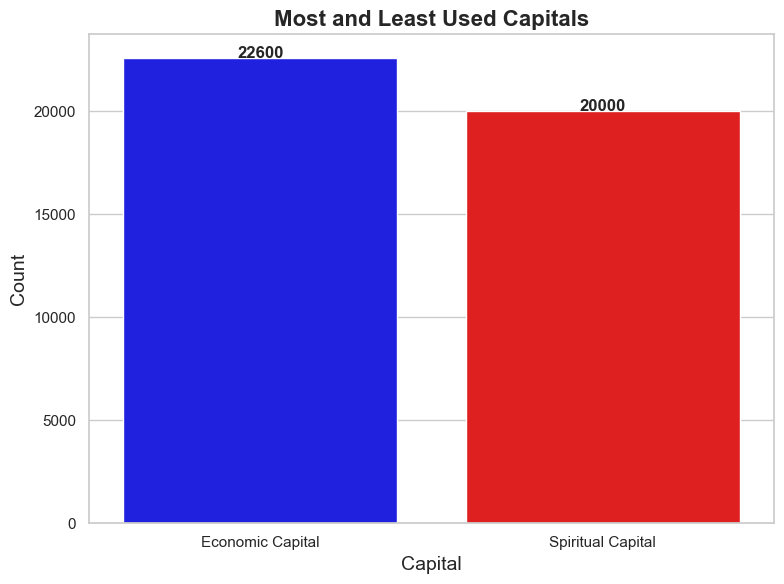

In [ ]:
# Set up the color palette for the most and least used capitals
palette = {most_used: 'blue', least_used: 'red'}

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")
barplot = sns.barplot(x=capital_counts.index, y=capital_counts.values, palette=palette)

# Add titles and labels
plt.title('Most and Least Used Capitals', fontsize=16, weight='bold')
plt.xlabel('Capital', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Display values on top of each bar
for i, value in enumerate(capital_counts.values):
    plt.text(i, value + 1, str(value), ha='center', fontsize=12, weight='bold')

# Customize the background color
plt.gca().set_facecolor('white')
plt.gcf().set_facecolor('white')

# Show the plot
plt.tight_layout()
plt.show()

# Most and Least Used Capitals by Age of Users

C:\Users\roohullah-pc\AppData\Local\Temp\ipykernel_29280\2493525875.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot = sns.boxplot(x='Predicted Capital', y='Age-Of-User', data=df, palette=palette)
C:\Users\roohullah-pc\AppData\Local\Temp\ipykernel_29280\2493525875.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  boxplot.set_xticklabels(boxplot.get_xticklabels(), rotation=45, ha='right', fontsize=12)
C:\Users\roohullah-pc\AppData\Local\Temp\ipykernel_29280\2493525875.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  boxplot.set_yticklabels(boxplot.get_yticks(), fontsize=12)


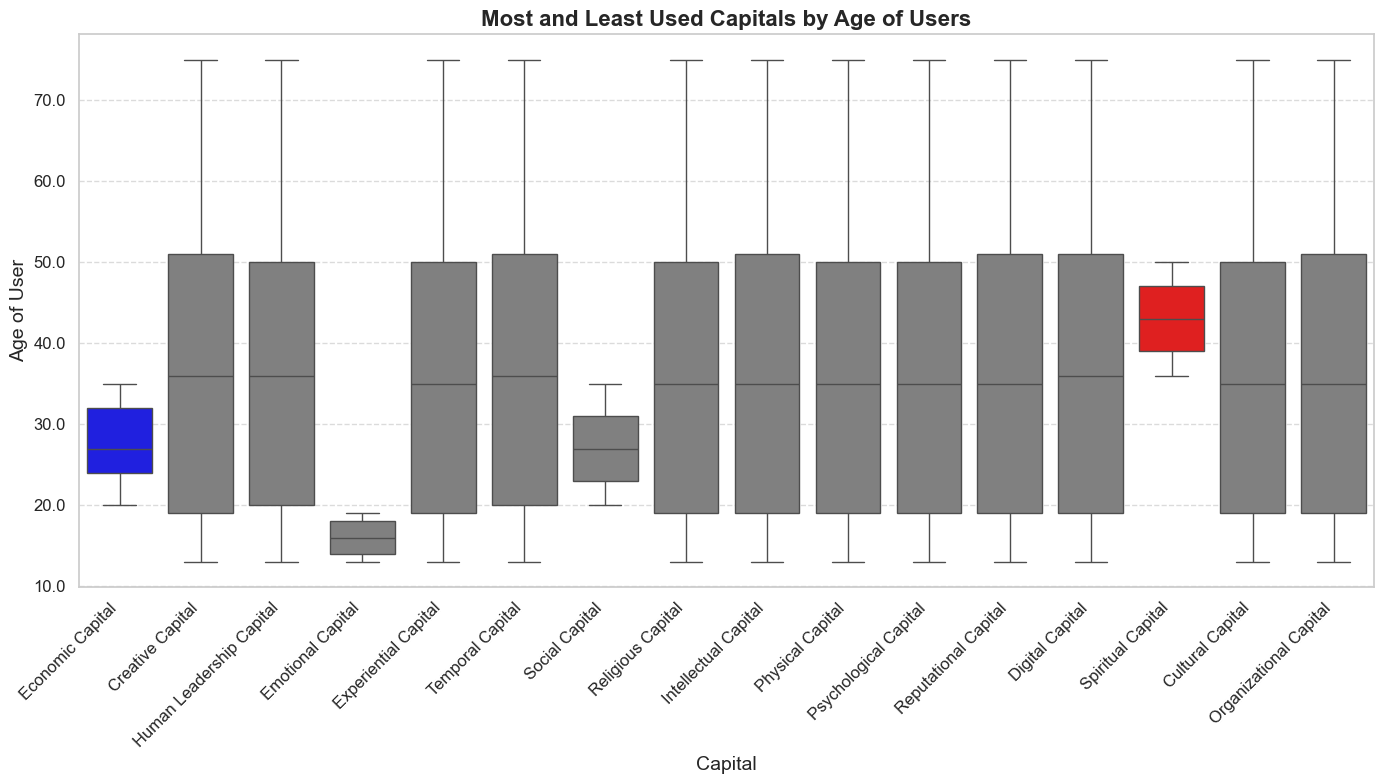

In [ ]:
unique_capitals = df['Predicted Capital'].unique()
palette = {capital: 'grey' for capital in unique_capitals}
palette[most_used] = 'blue'
palette[least_used] = 'red'
plt.figure(figsize=(14, 8))
sns.set(style="whitegrid")

# Create a box plot with custom color mapping
boxplot = sns.boxplot(x='Predicted Capital', y='Age-Of-User', data=df, palette=palette)

# Add titles and labels
plt.title('Most and Least Used Capitals by Age of Users', fontsize=16, weight='bold')
plt.xlabel('Capital', fontsize=14)
plt.ylabel('Age of User', fontsize=14)

# Customize the x-axis and y-axis labels
boxplot.set_xticklabels(boxplot.get_xticklabels(), rotation=45, ha='right', fontsize=12)
boxplot.set_yticklabels(boxplot.get_yticks(), fontsize=12)

# Add gridlines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Customize the background color
plt.gca().set_facecolor('white')
plt.gcf().set_facecolor('white')

# Show the plot
plt.tight_layout()
plt.show()

# Count occurrences of each country

In [ ]:
country_counts = df['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']


In [ ]:
country_counts

,Country,Count
0,Australia,17709
1,India,16957
2,Pakistan,13765
3,Sweden,13431
4,Germany,13246
5,UK,13192
6,Afghanistan,12622
7,Japan,12361
8,Canada,11774
9,Spain,11772


# Identify most and least used countries

In [ ]:
most_used_country = country_counts.iloc[0]
least_used_country = country_counts.iloc[-1]

In [ ]:
most_used_country

Country    Australia
Count          17709
Name: 0, dtype: object

In [ ]:
least_used_country

Country    Egypt
Count       5073
Name: 33, dtype: object

# Distribution of Capital Use by Country

In [ ]:
! pip install plotly


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import plotly.express as px
fig = px.bar(country_counts, x='Country', y='Count',
             title='Distribution of Capital Use by Country',
             labels={'Country': 'Country', 'Count': 'Number of Entries'},
             color='Count',
             color_continuous_scale=px.colors.sequential.Viridis)

# Add annotations for the most and least used countries
fig.add_annotation(
    x=most_used_country['Country'], 
    y=most_used_country['Count'],
    text=f"Most Used: {most_used_country['Country']} ({most_used_country['Count']})",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-40,
    font=dict(color="red")
)

fig.add_annotation(
    x=least_used_country['Country'], 
    y=least_used_country['Count'],
    text=f"Least Used: {least_used_country['Country']} ({least_used_country['Count']})",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=40,
    font=dict(color="blue")
)

# Show the plot
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

C:\Users\roohullah-pc\AppData\Local\Temp\ipykernel_29280\2272360197.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\roohullah-pc\AppData\Local\Temp\ipykernel_29280\2272360197.py:13: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\roohullah-pc\AppData\Local\Temp\ipykernel_29280\2272360197.py:14: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



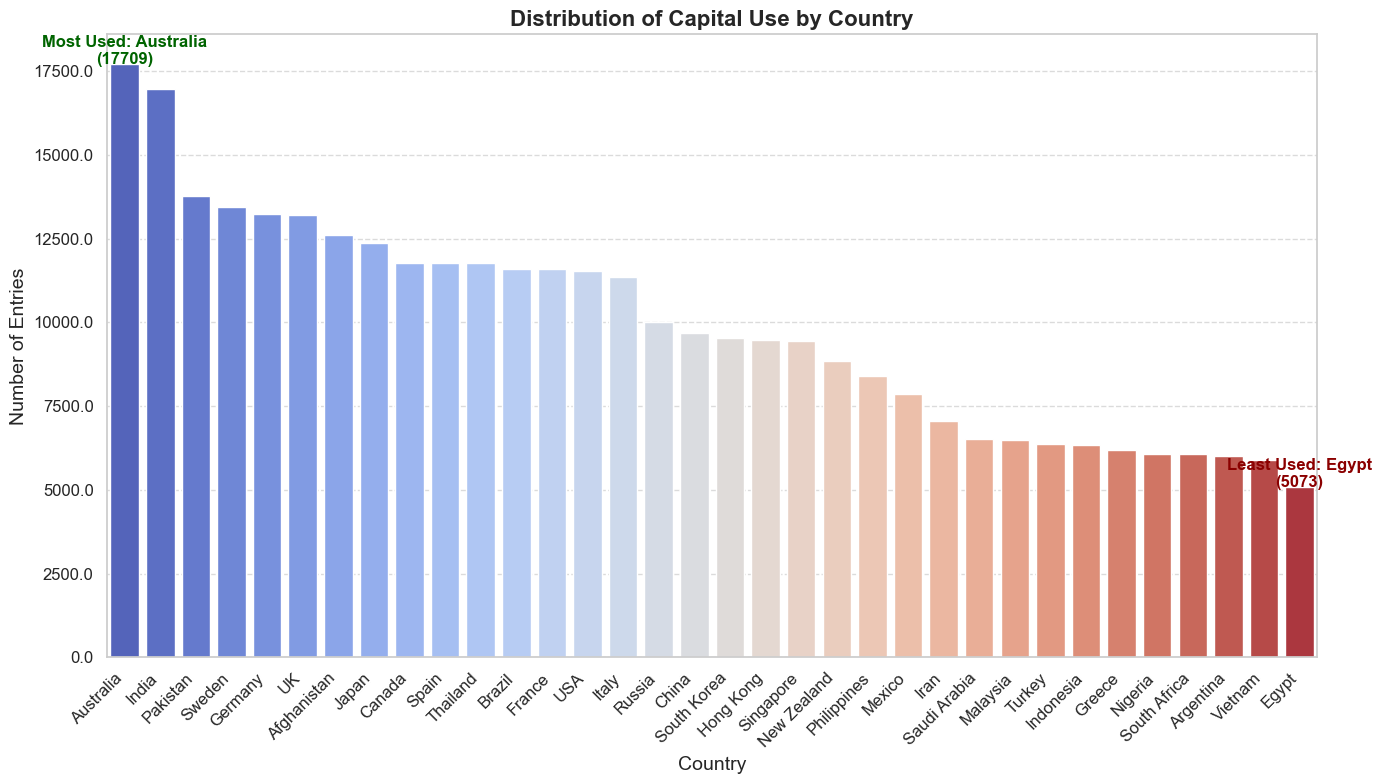

In [ ]:
plt.figure(figsize=(14, 8))
sns.set(style="whitegrid")

# Create a bar plot with a color palette
barplot = sns.barplot(x='Country', y='Count', data=country_counts, palette='coolwarm')

# Add titles and labels
plt.title('Distribution of Capital Use by Country', fontsize=16, weight='bold')
plt.xlabel('Country', fontsize=14)
plt.ylabel('Number of Entries', fontsize=14)

# Customize the bar plot
barplot.set_xticklabels(barplot.get_xticklabels(), rotation=45, ha='right', fontsize=12)
barplot.set_yticklabels(barplot.get_yticks(), fontsize=12)

# Annotate the most and least used countries
plt.text(most_used_country.name, most_used_country['Count'] + 2,
         f'Most Used: {most_used_country["Country"]}\n({most_used_country["Count"]})',
         color='darkgreen', ha='center', fontsize=12, weight='bold')

plt.text(least_used_country.name, least_used_country['Count'] + 2,
         f'Least Used: {least_used_country["Country"]}\n({least_used_country["Count"]})',
         color='darkred', ha='center', fontsize=12, weight='bold')

# Add gridlines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

# Word Frequency Distribution

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist


C:\Users\roohullah-pc\AppData\Local\Temp\ipykernel_29280\1089011362.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




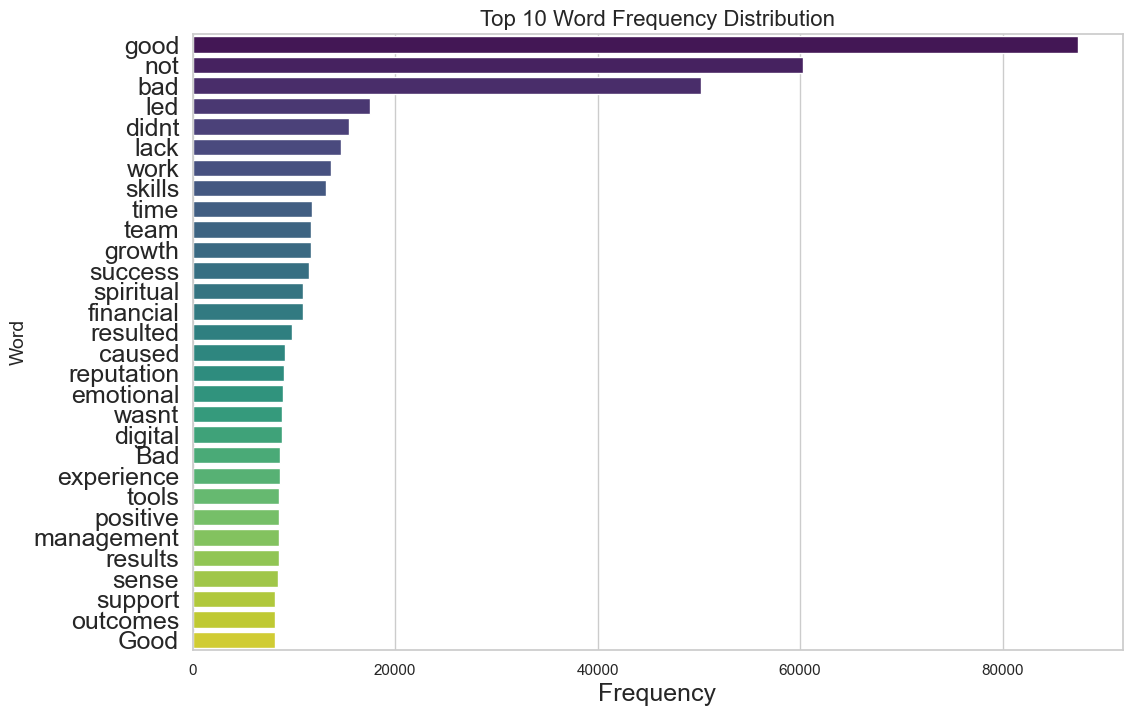

In [ ]:
# Tokenize the words
all_words = word_tokenize(' '.join(df['Text_without_stopwords']))

# Get the frequency distribution
word_freq = FreqDist(all_words)

# Convert the frequency distribution to a DataFrame
word_freq_df = pd.DataFrame(word_freq.most_common(30), columns=['Word', 'Frequency'])

# Create a seaborn barplot
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Word', data=word_freq_df, palette='viridis')

plt.title('Top 10 Word Frequency Distribution', fontsize=16)
plt.xlabel('Frequency', fontsize=18)
plt.ylabel('Word', fontsize=14)

# Increase y-axis word font size
plt.yticks(fontsize=18)

plt.show()


In [ ]:
print(df.columns)


Index(['Capitals Text Generation', 'Sentiment Label', 'Predicted Capital',
       'User-Id', 'Social-Accounts', 'Date', 'Time', 'Day', 'Country',
       'Age-Of-User', 'Clean_Capitals Text Generation', 'Tokens',
       'Normalized_text', 'Text_without_stopwords', 'text_length'],
      dtype='object')


# Plot Age-Of-User and Country Relation
This graph shows the distribution of ages for users in different countries

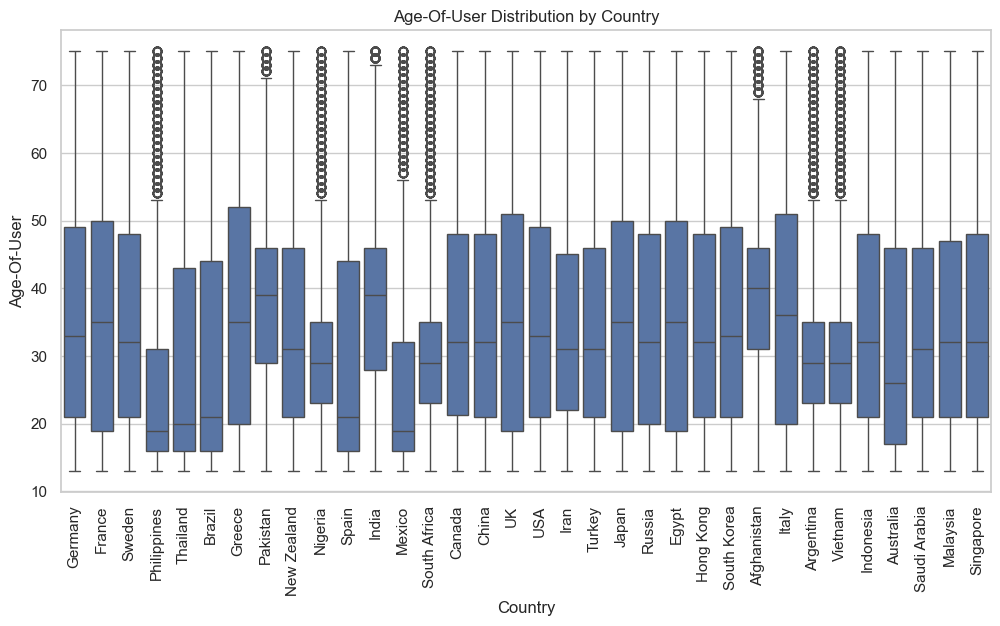

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Country', y='Age-Of-User', data=df)
plt.title('Age-Of-User Distribution by Country')
plt.xticks(rotation=90)
plt.show()

# Plot Age-Of-User and Predicted Capital Relation
This graph displays the distribution of user ages for each predicted capital type. 
This helps in understanding which age groups are associated with which types of predicted capital.

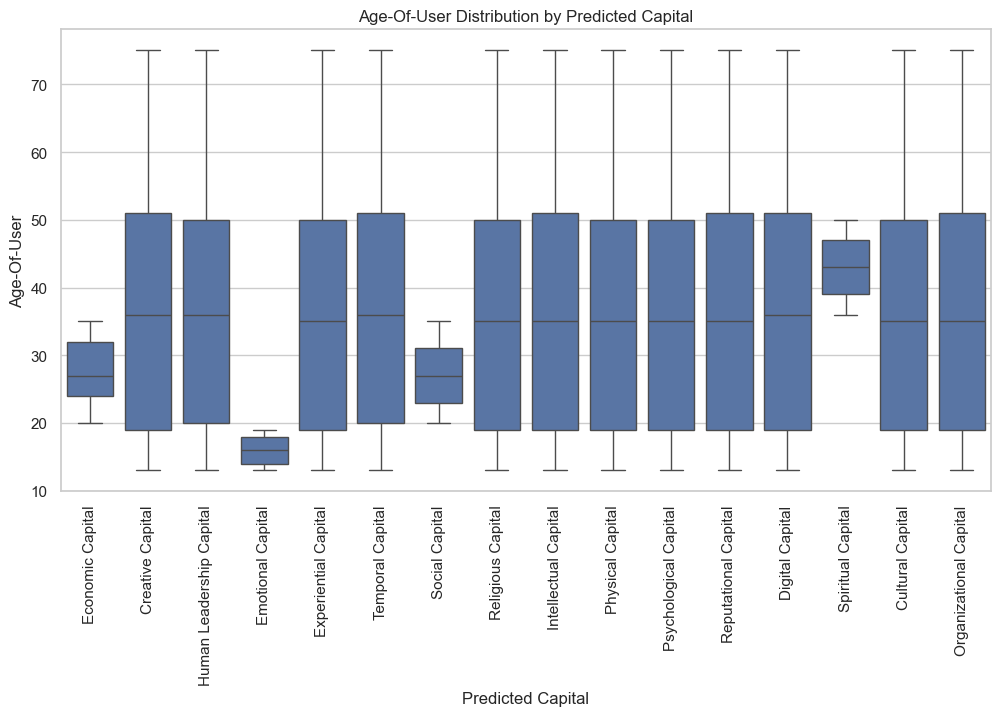

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Predicted Capital', y='Age-Of-User', data=df)
plt.title('Age-Of-User Distribution by Predicted Capital')
plt.xticks(rotation=90)
plt.show()

# Plot the count of Predicted Capital by Age-Of-User and Country
This graph shows the count of each type of predicted capital for each country. The hue differentiates the types of predicted capital, making it clear how many messages of each type are generated by users from different countries.
Helps in understanding the distribution and popularity of different capital types across countries, providing insights into geographical trends and cultural preferences.

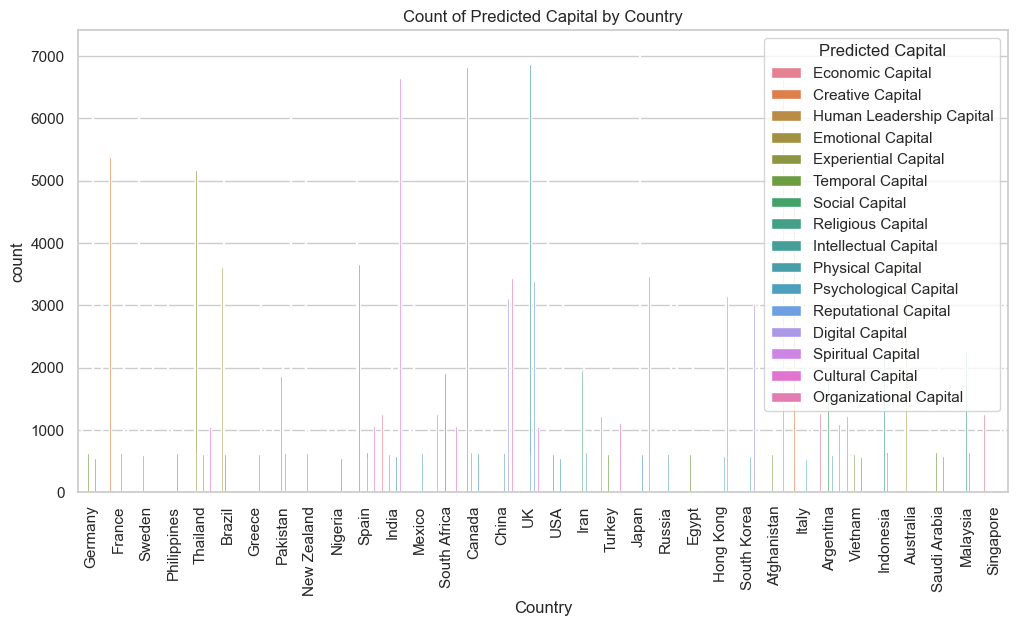

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Country', hue='Predicted Capital')
plt.title('Count of Predicted Capital by Country')
plt.xticks(rotation=90)
plt.show()

# Plot the count of Predicted Capital by Age-Of-User
## Purpose: 
This histogram shows the count of each type of predicted capital for different ages. The stacking allows for a clear comparison of the distribution of capital types across different age groups.
## Usage:
Useful for identifying which age groups are most likely to generate specific types of capital messages, highlighting age-related trends in message generation.

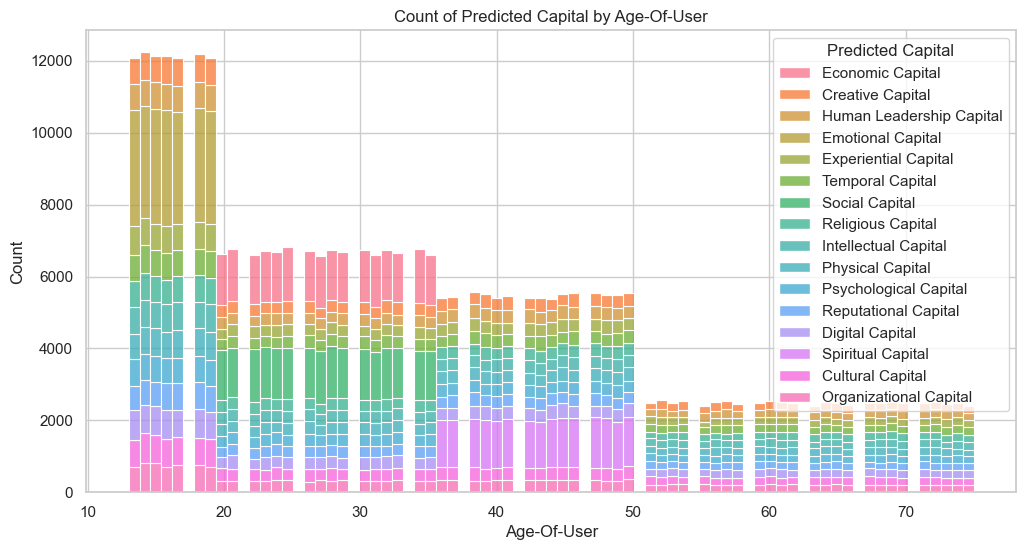

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Age-Of-User', hue='Predicted Capital', multiple="stack")
plt.title('Count of Predicted Capital by Age-Of-User')
plt.show()

# Prepare Features and Labels

In [ ]:
X = df['Text_without_stopwords']
y = df[['Predicted Capital', 'Sentiment Label']].copy()

# Model Training


In [ ]:
import numpy as np
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical


In [ ]:
# =======================
# 1. Data Preprocessing
# =======================

# Encode labels
label_encoder_capital = LabelEncoder()
label_encoder_sentiment = LabelEncoder()

y['Capital'] = label_encoder_capital.fit_transform(y['Predicted Capital'])
y['Sentiment'] = label_encoder_sentiment.fit_transform(y['Sentiment Label'])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# One-hot encode both targets
y_train_sentiment = to_categorical(y_train['Sentiment'])
y_test_sentiment = to_categorical(y_test['Sentiment'])
y_train_capital = to_categorical(y_train['Capital'])
y_test_capital = to_categorical(y_test['Capital'])

# Tokenizer
MAX_WORDS = 15000
MAX_LEN = 150

tokenizer = Tokenizer(num_words=MAX_WORDS, lower=True, split=' ')
tokenizer.fit_on_texts(X_train.values)

X_train_seq = tokenizer.texts_to_sequences(X_train.values)
X_test_seq = tokenizer.texts_to_sequences(X_test.values)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN)
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN)


In [ ]:
X_train

248000    ample time allowed thoughtful exceptionally po...
315647                              leaders leadership weak
252663    first weeks events not good leaving many disap...
275401    Failures werent exactly rare insufficient hand...
146065    ample time allowed thoughtful impressively pos...
                                ...                        
119879    casual approach dress speech often resulted so...
259178           Good reading expands intellectual horizons
131932    ergonomic furniture office enhanced comfort pr...
146867       Bad digital solutions stifling creative output
121958    Strong social networks not bad enhancing colla...
Name: Text_without_stopwords, Length: 268823, dtype: object

In [ ]:
X_train_seq

[[375, 12, 311, 305, 604, 19, 7, 32],
 [24, 36, 200],
 [965, 3147, 511, 2, 1, 1440, 445, 3704],
 [539, 96, 232, 2285, 224, 104, 38],
 [375, 12, 311, 305, 679, 19, 7, 32],
 [4, 73, 112, 40],
 [9, 12, 27, 309, 18, 3, 140, 28],
 [444, 480, 174, 227, 40],
 [1, 149, 1869, 490, 445, 54],
 [224, 16, 82, 157, 2, 1, 55, 161, 280, 1, 2909],
 [2, 1, 540, 264, 117, 361, 227, 40, 29, 1222],
 [9, 12, 27, 63, 5, 220, 430, 269],
 [225, 498, 59, 453, 49, 230],
 [1, 91, 8, 848, 158, 720, 65, 89],
 [681, 413, 56, 798, 795],
 [1, 695, 233, 1008, 46, 428],
 [500, 187, 2, 1, 79, 2, 1, 69],
 [409, 20, 31, 1, 223, 1188, 65],
 [24, 68, 877, 65, 150, 356, 275, 932, 4, 109, 838, 36, 8, 576, 128, 671],
 [22, 6, 515, 54],
 [3, 61, 167, 20, 75, 18, 3, 72],
 [19, 259, 2713, 1354, 360, 2837, 128, 345],
 [1, 1113, 192, 138, 478, 49, 36],
 [94, 90, 12, 5, 2, 1, 40, 234],
 [156, 1, 211, 319, 49, 731, 42, 77],
 [659, 34, 164, 352, 188, 30, 76, 2736],
 [279, 1, 59, 1027, 349, 13],
 [726, 4, 71, 2, 1, 29],
 [1614, 102, 168

In [ ]:
X_train_pad

array([[   0,    0,    0, ...,   19,    7,   32],
       [   0,    0,    0, ...,   24,   36,  200],
       [   0,    0,    0, ..., 1440,  445, 3704],
       ...,
       [   0,    0,    0, ...,  170,  507,   39],
       [   0,    0,    0, ..., 2421,   35,  783],
       [   0,    0,    0, ...,  203,   98,  524]],
      shape=(268823, 150), dtype=int32)

In [ ]:
# =======================
# 2. Multi-output Model
# =======================
inputs = Input(shape=(MAX_LEN,))

x = Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN)(inputs)
x = SpatialDropout1D(0.3)(x)
x = LSTM(64, dropout=0.5, recurrent_dropout=0.5)(x)
x = Dropout(0.5)(x)

# Two outputs
sentiment_out = Dense(y_train_sentiment.shape[1], activation='softmax', name="sentiment")(x)
capital_out = Dense(y_train_capital.shape[1], activation='softmax', name="capital")(x)

# Define model
multi_model = Model(inputs=inputs, outputs=[sentiment_out, capital_out])

multi_model.compile(
    loss={'sentiment': 'categorical_crossentropy', 'capital': 'categorical_crossentropy'},
    optimizer='adam',
    metrics={'sentiment': 'accuracy', 'capital': 'accuracy'})

multi_model.summary()

c:\Users\roohullah-pc\Downloads\Final_Model\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 150, 128)  │  1,920,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 150, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     49,408 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment (Dense)   │ (None, 2)         │        130 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capital (Dense)     │ (None, 16)        │      1,040 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,970,578 (7.52 MB)

 Trainable params: 1,970,578 (7.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train
history = multi_model.fit(
    X_train_pad,
    {'sentiment': y_train_sentiment, 'capital': y_train_capital},
    validation_data=(X_test_pad, {'sentiment': y_test_sentiment, 'capital': y_test_capital}),
    epochs=5,
    batch_size=32,
    verbose=2
)


Epoch 1/5
8401/8401 - 993s - 118ms/step - capital_accuracy: 0.9068 - capital_loss: 0.3339 - loss: 0.4872 - sentiment_accuracy: 0.9393 - sentiment_loss: 0.1533 - val_capital_accuracy: 0.9935 - val_capital_loss: 0.0239 - val_loss: 0.0576 - val_sentiment_accuracy: 0.9874 - val_sentiment_loss: 0.0337
Epoch 2/5
8401/8401 - 1238s - 147ms/step - capital_accuracy: 0.9814 - capital_loss: 0.0668 - loss: 0.1162 - sentiment_accuracy: 0.9838 - sentiment_loss: 0.0493 - val_capital_accuracy: 0.9967 - val_capital_loss: 0.0146 - val_loss: 0.0306 - val_sentiment_accuracy: 0.9930 - val_sentiment_loss: 0.0160
Epoch 3/5
8401/8401 - 1085s - 129ms/step - capital_accuracy: 0.9869 - capital_loss: 0.0470 - loss: 0.0793 - sentiment_accuracy: 0.9892 - sentiment_loss: 0.0323 - val_capital_accuracy: 0.9977 - val_capital_loss: 0.0103 - val_loss: 0.0218 - val_sentiment_accuracy: 0.9950 - val_sentiment_loss: 0.0115
Epoch 4/5
8401/8401 - 1138s - 136ms/step - capital_accuracy: 0.9890 - capital_loss: 0.0375 - loss: 0.063

In [ ]:

# =======================
# 3. Save Model + Preprocessing
# =======================
multi_model.save("Final_Model/multi_model.h5")

with open("Final_Model/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("Final_Model/label_encoder_sentiment.pkl", "wb") as f:
    pickle.dump(label_encoder_sentiment, f)

with open("Final_Model/label_encoder_capital.pkl", "wb") as f:
    pickle.dump(label_encoder_capital, f)

print("Model, tokenizer, and encoders saved!")



Model, tokenizer, and encoders saved!


In [ ]:
# =======================
# 4. Reload + Predict
# =======================
# Reload model
loaded_model = load_model("Final_Model/multi_model.h5")

# Reload preprocessing
with open("Final_Model/tokenizer.pkl", "rb") as f:
    loaded_tokenizer = pickle.load(f)

with open("Final_Model/label_encoder_sentiment.pkl", "rb") as f:
    loaded_label_encoder_sentiment = pickle.load(f)

with open("Final_Model/label_encoder_capital.pkl", "rb") as f:
    loaded_label_encoder_capital = pickle.load(f)


In [ ]:

# Example prediction
sample_text = ["This movie was fantastic!"]

seq = loaded_tokenizer.texts_to_sequences(sample_text)
pad = pad_sequences(seq, maxlen=MAX_LEN)

sentiment_pred, capital_pred = loaded_model.predict(pad)

sentiment_class = np.argmax(sentiment_pred, axis=1)
capital_class = np.argmax(capital_pred, axis=1)

decoded_sentiment = loaded_label_encoder_sentiment.inverse_transform(sentiment_class)
decoded_capital = loaded_label_encoder_capital.inverse_transform(capital_class)

print("Predicted Sentiment:", decoded_sentiment)
print("Predicted Capital:", decoded_capital)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step
Predicted Sentiment: ['Positive']
Predicted Capital: ['Human Leadership Capital']


In [ ]:
# Example prediction with actual label

# Pick a sample index from the test set
sample_idx = 0
sample_text = [X_test.iloc[sample_idx]]
actual_sentiment = y_test.iloc[sample_idx]['Sentiment']
actual_capital = y_test.iloc[sample_idx]['Capital']

# Preprocess
seq = loaded_tokenizer.texts_to_sequences(sample_text)
pad = pad_sequences(seq, maxlen=MAX_LEN)

# Predict
sentiment_pred, capital_pred = loaded_model.predict(pad)
sentiment_class = np.argmax(sentiment_pred, axis=1)
capital_class = np.argmax(capital_pred, axis=1)

# Decode predictions
decoded_sentiment = loaded_label_encoder_sentiment.inverse_transform(sentiment_class)[0]
decoded_capital = loaded_label_encoder_capital.inverse_transform(capital_class)[0]

# Decode actuals
actual_sentiment_label = loaded_label_encoder_sentiment.inverse_transform([actual_sentiment])[0]
actual_capital_label = loaded_label_encoder_capital.inverse_transform([actual_capital])[0]

print("Text:", sample_text[0])
print("Predicted Sentiment:", decoded_sentiment)
print("Actual Sentiment:", actual_sentiment_label)
print("Predicted Capital:", decoded_capital)
print("Actual Capital:", actual_capital_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Text: Sacred rituals feel disconnected
Predicted Sentiment: Negative
Actual Sentiment: Negative
Predicted Capital: Religious Capital
Actual Capital: Religious Capital


In [ ]:
# Example predictions for 5 test samples

for sample_idx in range(5):
    sample_text = [X_test.iloc[sample_idx]]
    actual_sentiment = y_test.iloc[sample_idx]['Sentiment']
    actual_capital = y_test.iloc[sample_idx]['Capital']

    # Preprocess
    seq = loaded_tokenizer.texts_to_sequences(sample_text)
    pad = pad_sequences(seq, maxlen=MAX_LEN)

    # Predict
    sentiment_pred, capital_pred = loaded_model.predict(pad)
    sentiment_class = np.argmax(sentiment_pred, axis=1)
    capital_class = np.argmax(capital_pred, axis=1)

    # Decode predictions
    decoded_sentiment = loaded_label_encoder_sentiment.inverse_transform(sentiment_class)[0]
    decoded_capital = loaded_label_encoder_capital.inverse_transform(capital_class)[0]

    # Decode actuals
    actual_sentiment_label = loaded_label_encoder_sentiment.inverse_transform([actual_sentiment])[0]
    actual_capital_label = loaded_label_encoder_capital.inverse_transform([actual_capital])[0]

    print(f"Sample {sample_idx+1}:")
    print("Text:", sample_text[0])
    print("Predicted Sentiment:", decoded_sentiment)
    print("Actual Sentiment:", actual_sentiment_label)
    print("Predicted Capital:", decoded_capital)
    print("Actual Capital:", actual_capital_label)
    print("-" * 50)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Sample 1:
Text: Sacred rituals feel disconnected
Predicted Sentiment: Negative
Actual Sentiment: Negative
Predicted Capital: Religious Capital
Actual Capital: Religious Capital
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Sample 2:
Text: Focused strategies clear objectives led effective execution
Predicted Sentiment: Positive
Actual Sentiment: Positive
Predicted Capital: Organizational Capital
Actual Capital: Organizational Capital
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Sample 3:
Text: not good use religious teachings harmful purposes
Predicted Sentiment: Negative
Actual Sentiment: Negative
Predicted Capital: Religious Capital
Actual Capital: Religious Capital
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Sample 4:
Text: leader phenomenal
Predicted Sentiment: Positive
Actual Sentiment: Positive
Predicted Capital: 

2101/2101 ━━━━━━━━━━━━━━━━━━━━ 50s 24ms/step
Sentiment Metrics:
Accuracy: 0.9954, Precision: 0.9954, Recall: 0.9954, F1-score: 0.9954

Capital Metrics:
Accuracy: 0.9985, Precision: 0.9985, Recall: 0.9985, F1-score: 0.9985


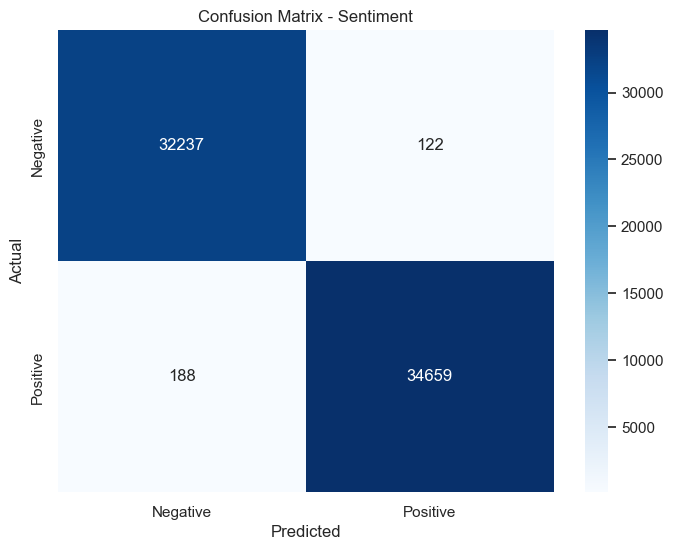

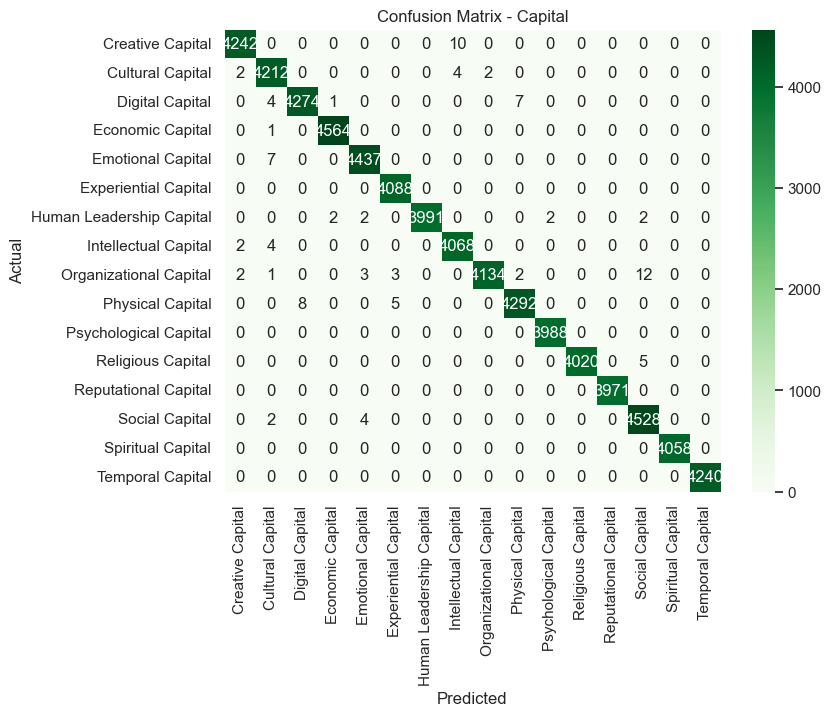

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the whole test set
sentiment_pred, capital_pred = loaded_model.predict(X_test_pad)
y_pred_sentiment = np.argmax(sentiment_pred, axis=1)
y_pred_capital = np.argmax(capital_pred, axis=1)
y_true_sentiment = y_test['Sentiment'].values
y_true_capital = y_test['Capital'].values

# Metrics for Sentiment
acc_sent = accuracy_score(y_true_sentiment, y_pred_sentiment)
prec_sent = precision_score(y_true_sentiment, y_pred_sentiment, average='weighted')
rec_sent = recall_score(y_true_sentiment, y_pred_sentiment, average='weighted')
f1_sent = f1_score(y_true_sentiment, y_pred_sentiment, average='weighted')

# Metrics for Capital
acc_cap = accuracy_score(y_true_capital, y_pred_capital)
prec_cap = precision_score(y_true_capital, y_pred_capital, average='weighted')
rec_cap = recall_score(y_true_capital, y_pred_capital, average='weighted')
f1_cap = f1_score(y_true_capital, y_pred_capital, average='weighted')

print("Sentiment Metrics:")
print(f"Accuracy: {acc_sent:.4f}, Precision: {prec_sent:.4f}, Recall: {rec_sent:.4f}, F1-score: {f1_sent:.4f}")
print("\nCapital Metrics:")
print(f"Accuracy: {acc_cap:.4f}, Precision: {prec_cap:.4f}, Recall: {rec_cap:.4f}, F1-score: {f1_cap:.4f}")

# Confusion Matrix for Sentiment
cm_sent = confusion_matrix(y_true_sentiment, y_pred_sentiment)
plt.figure(figsize=(8,6))
sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Blues',
            xticklabels=loaded_label_encoder_sentiment.classes_,
            yticklabels=loaded_label_encoder_sentiment.classes_)
plt.title("Confusion Matrix - Sentiment")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Confusion Matrix for Capital
cm_cap = confusion_matrix(y_true_capital, y_pred_capital)
plt.figure(figsize=(8,6))
sns.heatmap(cm_cap, annot=True, fmt='d', cmap='Greens',
            xticklabels=loaded_label_encoder_capital.classes_,
            yticklabels=loaded_label_encoder_capital.classes_)
plt.title("Confusion Matrix - Capital")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()